In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Affichage des graphiques dans le notebook
%matplotlib inline
sns.set_theme(style="whitegrid")

# Chargement des données
df = pd.read_csv('../data/processed_data.csv')
df['full_timestamp'] = pd.to_datetime(df['full_timestamp'])
print(f"Dataset chargé : {df.shape[0]} transactions.")

Dataset chargé : 48590 transactions.


In [8]:
# 2. IQR pour les Frais
Q1 = df['fee_rate'].quantile(0.25)
Q3 = df['fee_rate'].quantile(0.75)
IQR = Q3 - Q1
upper_bound_fee = Q3 + 1.5 * IQR
df['stat_outlier_fee'] = (df['fee_rate'] > upper_bound_fee).astype(int)

# 3. Z-Score pour le Volume (Log-transformé)
df['z_score_volume'] = np.abs(stats.zscore(df['log_total_input'].fillna(0)))
df['stat_outlier_volume'] = ((df['z_score_volume'] > 2) | (df['z_score_volume'] < -2)).astype(int)

# 4. Sauvegarde
print(f"✅ Analyse terminée. {df['stat_outlier_fee'].sum()} anomalies de frais détectées.")

✅ Analyse terminée. 5053 anomalies de frais détectées.


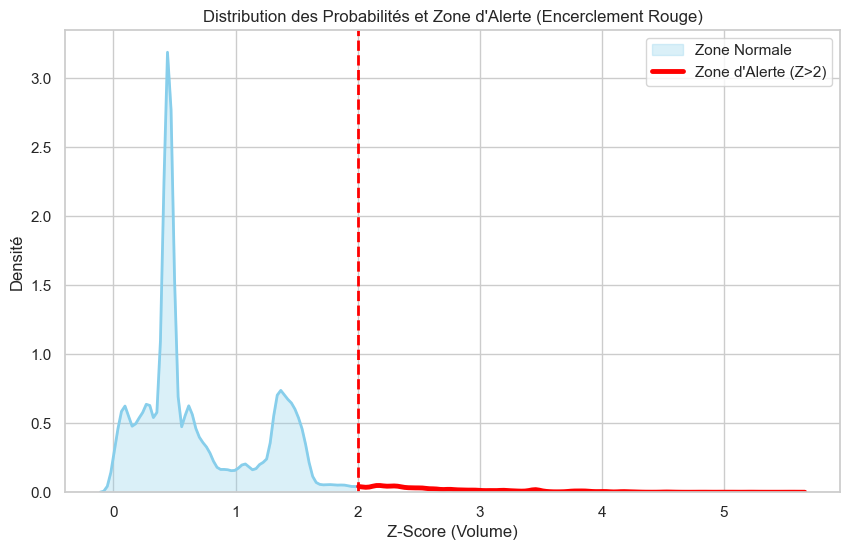

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np # Assure-toi d'importer Numpy

plt.figure(figsize=(10, 6))

# 1. On trace UNIQUEMENT la ligne du KDE
ax = sns.kdeplot(df['z_score_volume'], color="skyblue", bw_adjust=0.5, linewidth=2)

# 2. Récupération des données du tracé
line = ax.lines[0]
x = np.array(line.get_xdata()) # Conversion forcée en Array NumPy
y = np.array(line.get_ydata())

# 3. On colorie UNIQUEMENT la zone "NORMALE" en bleu (0 à 2)
# On sature le remplissage pour la zone normale
plt.fill_between(x, 0, y, where=(x < 2.0), color='skyblue', alpha=0.3, label='Zone Normale')

# --- NOUVEAU : Encerclement agressif en rouge après Z=2 ---
# On trace la même ligne, mais en ROUGE et ÉPAISSE pour la partie > 2
# L'opérateur `>=` assure une jointure parfaite au seuil
mask_anomalie = (x >= 2.0)
plt.plot(x[mask_anomalie], y[mask_anomalie], color='red', linewidth=3.5, label='Zone d\'Alerte (Z>2)')

# 4. Ajout du seuil visuel (ligne verticale)
plt.axvline(x=2, color='red', linestyle='--', linewidth=2)

# Habillage
plt.title("Distribution des Probabilités et Zone d'Alerte (Encerclement Rouge)")
plt.xlabel("Z-Score (Volume)")
plt.ylabel("Densité")
plt.legend()
plt.show()

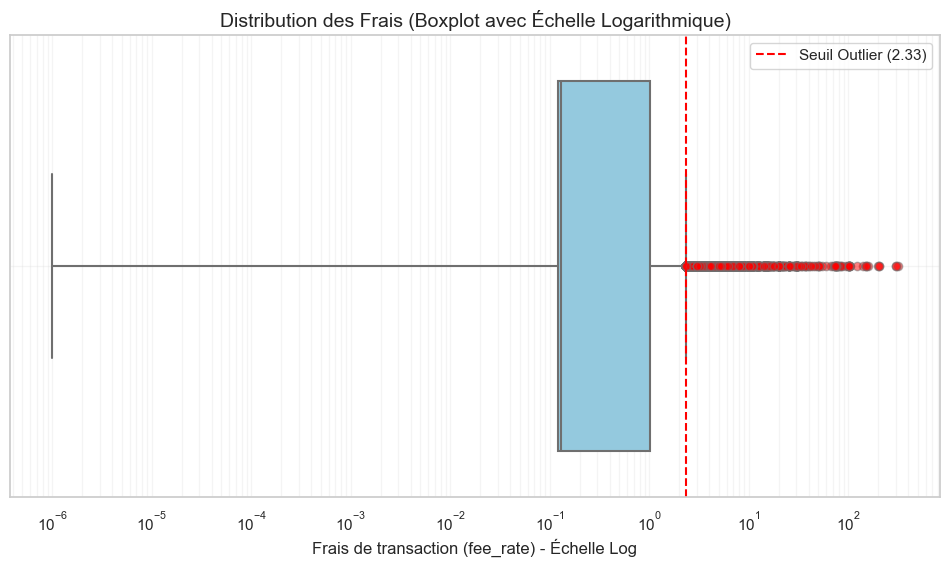

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(12, 6))

# 1. On crée le Boxplot
# On ajoute une petite constante (1e-6) pour éviter le log(0) si des frais sont à 0
ax = sns.boxplot(x=df['fee_rate'] + 1e-6, color='skyblue', 
                 flierprops={"marker": "o", "markerfacecolor": "red", "alpha": 0.5},
                 linewidth=1.5)

# 2. On passe l'axe X en échelle Logarithmique
ax.set_xscale('log')

# 3. Calcul et ajout du seuil IQR visuel
Q3 = df['fee_rate'].quantile(0.75)
IQR = Q3 - df['fee_rate'].quantile(0.25)
upper_bound = Q3 + 1.5 * IQR

# On trace le seuil (attention, la ligne sera droite sur l'échelle log)
plt.axvline(x=upper_bound, color='red', linestyle='--', label=f'Seuil Outlier ({upper_bound:.2f})')

# 4. Habillage
plt.title("Distribution des Frais (Boxplot avec Échelle Logarithmique)", fontsize=14)
plt.xlabel("Frais de transaction (fee_rate) - Échelle Log", fontsize=12)
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.legend()

plt.show()

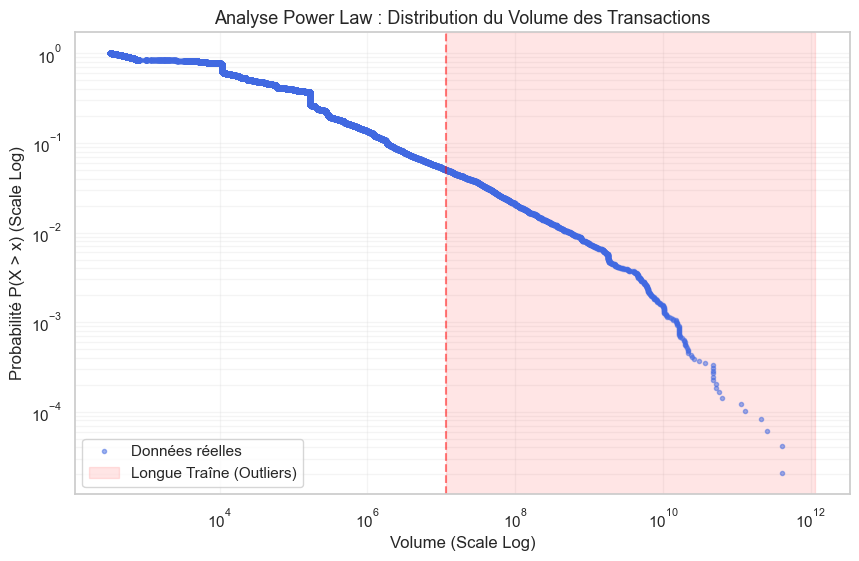

In [50]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Préparation des données (on enlève les zéros pour le log)
clean_data = df[df['total_input'] > 0]['total_input'].dropna()
data_sorted = np.sort(clean_data)

# Calcul de la Probabilité Complémentaire Cumulée (CCDF)
# P(X > x)
y = 1. - np.arange(1, len(data_sorted) + 1) / len(data_sorted)

plt.figure(figsize=(10, 6))

# 2. Tracé Log-Log (Points bleus)
plt.loglog(data_sorted, y, marker='.', linestyle='none', color='royalblue', alpha=0.5, label='Données réelles')

# 3. Identification de la zone d'anomalie (95ème percentile)
# Correction technique : on utilise np.percentile pour un array numpy
seuil_95 = np.percentile(data_sorted, 95)
plt.axvspan(seuil_95, data_sorted.max(), color='red', alpha=0.1, label='Longue Traîne (Outliers)')

# 4. Habillage technique
plt.axvline(seuil_95, color='red', linestyle='--', alpha=0.5)
plt.title("Analyse Power Law : Distribution du Volume des Transactions", fontsize=13)
plt.xlabel("Volume (Scale Log)")
plt.ylabel("Probabilité P(X > x) (Scale Log)")
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.legend()

plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_11512\3801215826.py:4: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df_resampled = df.resample('10T', on='full_timestamp').agg({


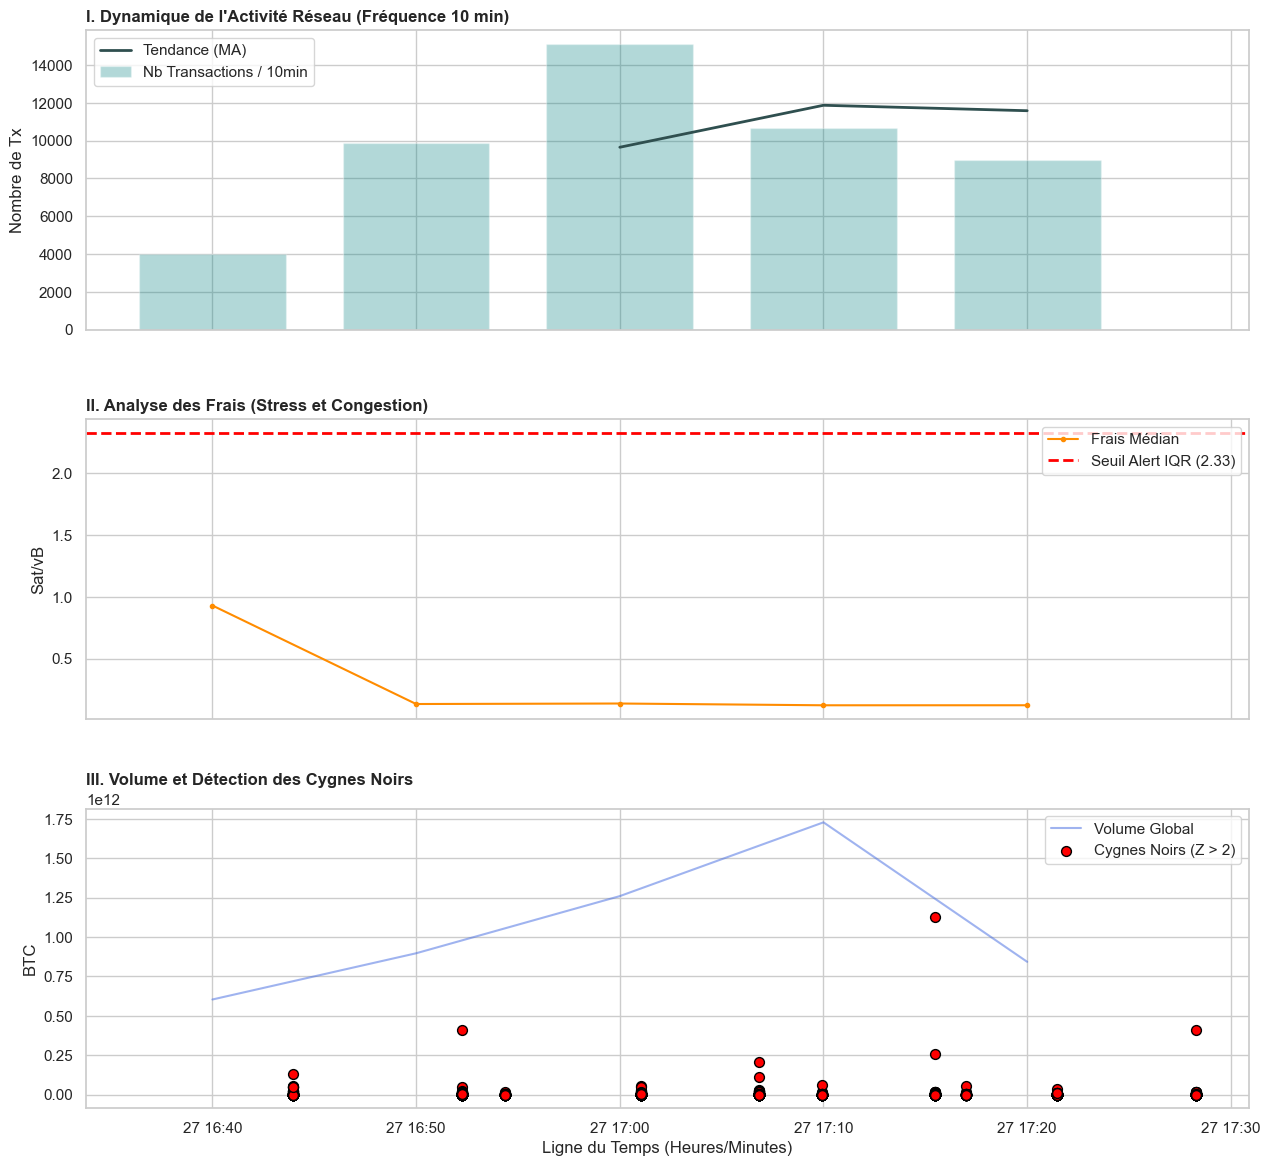

In [55]:
# --- 3. PRÉPARATION TEMPORELLE (RESAMPLING) ---

# On passe à 10 minutes ('10T') pour avoir des graphiques détaillés
df_resampled = df.resample('10T', on='full_timestamp').agg({
    'total_input': 'sum',
    'fee_rate': 'median',
    'full_timestamp': 'size'
}).rename(columns={'full_timestamp': 'tx_count'})

# Moyenne mobile pour lisser la tendance de l'activité
df_resampled['tx_moving_avg'] = df_resampled['tx_count'].rolling(window=3).mean()

# --- 4. VISUALISATION TIME SERIES ---

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 14), sharex=True)
plt.subplots_adjust(hspace=0.3)

# GRAPH I : ACTIVITÉ (Barres + Tendance)
# On réduit 'width' pour que les barres soient fines et précises
ax1.bar(df_resampled.index, df_resampled['tx_count'], color='teal', alpha=0.3, width=0.005, label='Nb Transactions / 10min')
ax1.plot(df_resampled.index, df_resampled['tx_moving_avg'], color='darkslategrey', linewidth=2, label='Tendance (MA)')
ax1.set_title("I. Dynamique de l'Activité Réseau (Fréquence 10 min)", fontsize=12, fontweight='bold', loc='left')
ax1.set_ylabel("Nombre de Tx")
ax1.legend(loc='upper left')

# GRAPH II : FRAIS (Détection IQR)
ax2.plot(df_resampled.index, df_resampled['fee_rate'], color='darkorange', marker='o', markersize=3, linewidth=1.5, label='Frais Médian')
ax2.axhline(y=upper_bound_fee, color='red', linestyle='--', linewidth=2, label=f'Seuil Alert IQR ({upper_bound_fee:.2f})')
# Coloriage de la zone d'alerte
ax2.fill_between(df_resampled.index, df_resampled['fee_rate'], upper_bound_fee, 
                 where=(df_resampled['fee_rate'] > upper_bound_fee), color='red', alpha=0.3)
ax2.set_title("II. Analyse des Frais (Stress et Congestion)", fontsize=12, fontweight='bold', loc='left')
ax2.set_ylabel("Sat/vB")
ax2.legend(loc='upper right')

# GRAPH III : VOLUME ET CYGNES NOIRS (Z-Score)
ax3.plot(df_resampled.index, df_resampled['total_input'], color='royalblue', alpha=0.5, label='Volume Global')
# Affichage des anomalies individuelles (les points rouges)
anomalies_vol = df[df['z_score_volume'] > 2]
ax3.scatter(anomalies_vol['full_timestamp'], anomalies_vol['total_input'], 
            color='red', s=50, edgecolors='black', label='Cygnes Noirs (Z > 2)', zorder=5)

ax3.set_title("III. Volume et Détection des Cygnes Noirs", fontsize=12, fontweight='bold', loc='left')
ax3.set_ylabel("BTC")
ax3.set_xlabel("Ligne du Temps (Heures/Minutes)")
ax3.legend(loc='upper right')

plt.show()